In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setting seed for reproducability
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Torch stuff
import torch
import torch.nn as nn
import random
from torch.utils.data import TensorDataset, DataLoader, random_split

In [2]:
# Import all stages of the data for FD001

# Feature Engineering (Default using Piecewise 125)
fe2_pw125_fd002_train = pd.read_csv("../../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/train_processed_rul_piecewise_125_fd002.csv")
fe2_pw125_fd002_test = pd.read_csv("../../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/test_processed_rul_piecewise_125_fd002.csv")

In [3]:
# Prepare the data at the sequence length
sequence_lengths = [30,50,70]
# Pick which dataset pair(s) you want to prepare
dataset_pairs = {
    "fe2_pw125": (fe2_pw125_fd002_train, fe2_pw125_fd002_test),
}


def gen_sequence(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    n = data_array.shape[0]
    for start, stop in zip(range(0, n - seq_length), range(seq_length, n)):
        yield data_array[start:stop, :]

def gen_labels(id_df, seq_length, label_col):
    data_array = id_df[label_col].values
    return data_array[seq_length:]

def build_sequence_data(train_df, test_df, seq_length, label_col="RUL"):
    # Features: everything except id/cycle/label
    seq_cols = [c for c in train_df.columns if c not in ["id", "cycle", label_col]]

    # Train windows + labels
    X_train = np.concatenate([
        np.array(list(gen_sequence(train_df[train_df["id"] == eid], seq_length, seq_cols)))
        for eid in train_df["id"].unique()
        if len(train_df[train_df["id"] == eid]) > seq_length
    ]).astype(np.float32)

    y_train = np.concatenate([
        gen_labels(train_df[train_df["id"] == eid], seq_length, [label_col])
        for eid in train_df["id"].unique()
        if len(train_df[train_df["id"] == eid]) > seq_length
    ]).astype(np.float32).reshape(-1, 1)

    # Test: last window per engine + last label
    X_test = np.array([
        test_df[test_df["id"] == eid][seq_cols].values[-seq_length:]
        for eid in test_df["id"].unique()
        if len(test_df[test_df["id"] == eid]) >= seq_length
    ]).astype(np.float32)

    mask = [len(test_df[test_df["id"] == eid]) >= seq_length for eid in test_df["id"].unique()]
    y_test = test_df.groupby("id")[label_col].nth(-1)[mask].values.astype(np.float32).reshape(-1, 1)

    return seq_cols, X_train, y_train, X_test, y_test

prepared_data = {}

for seq_len in sequence_lengths:
    for name, (tr_df, te_df) in dataset_pairs.items():
        seq_cols, X_train, y_train, X_test, y_test = build_sequence_data(tr_df, te_df, seq_len, label_col="RUL")

        prepared_data[(name, seq_len)] = {
            "seq_cols": seq_cols,
            "X_train": X_train,
            "y_train": y_train,
            "X_test": X_test,
            "y_test": y_test,
            "X_train_t": torch.tensor(X_train, dtype=torch.float32),
            "y_train_t": torch.tensor(y_train, dtype=torch.float32),
            "X_test_t": torch.tensor(X_test, dtype=torch.float32),
            "y_test_t": torch.tensor(y_test, dtype=torch.float32),
        }

        print(f"{name} | seq_len={seq_len}")
        print("  X_train:", X_train.shape, "y_train:", y_train.shape)
        print("  X_test :", X_test.shape,  "y_test :", y_test.shape)

fe2_pw125 | seq_len=30
  X_train: (45959, 30, 24) y_train: (45959, 1)
  X_test : (253, 30, 24) y_test : (253, 1)
fe2_pw125 | seq_len=50
  X_train: (40759, 50, 24) y_train: (40759, 1)
  X_test : (235, 50, 24) y_test : (235, 1)
fe2_pw125 | seq_len=70
  X_train: (35559, 70, 24) y_train: (35559, 1)
  X_test : (209, 70, 24) y_test : (209, 1)


In [4]:
# Define model architecture (2-layer RNN regression)
class BasicRNNRUL(nn.Module):
    def __init__(self, input_size, rnn1_hidden=100, rnn2_hidden=50, dropout=0.2):
        super().__init__()
        self.rnn1 = nn.RNN(
            input_size=input_size,
            hidden_size=rnn1_hidden,
            nonlinearity="tanh",
            batch_first=True,
        )
        self.dropout1 = nn.Dropout(dropout)

        self.rnn2 = nn.RNN(
            input_size=rnn1_hidden,
            hidden_size=rnn2_hidden,
            nonlinearity="tanh",
            batch_first=True,
        )
        self.dropout2 = nn.Dropout(dropout)

        self.fc = nn.Linear(rnn2_hidden, 1)

    def forward(self, x):
        out, _ = self.rnn1(x)
        out = self.dropout1(out)

        out, _ = self.rnn2(out)
        out = self.dropout2(out)

        last = out[:, -1, :]
        pred = self.fc(last)
        return pred


# RMSE loss for regression
class RMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_pred, y_true):
        return torch.sqrt(self.mse(y_pred, y_true) + self.eps)

In [5]:
def train_and_evaluate_rnn_all_datasets(
    prepared_data,
    sequence_lengths=(20,30),
    epochs=30,
    batch_size=128,
    lr=None,
    learning_rates=(1e-3, 5e-4, 1e-4),
    rnn1_hidden=100,
    rnn2_hidden=50,
    dropout=0.2,
    val_ratio=0.2,
    patience=5,
    seed=1234,
):
    """
    Train one BasicRNNRUL per dataset/sequence-length.
    Optimization uses MSE; reporting uses RMSE.
    Returns:
        results_df: summary table
        trained_models: dict[(dataset_name, seq_len, lr)] -> trained model
        histories: dict[(dataset_name, seq_len, lr)] -> {'train_rmse': [...], 'val_rmse': [...]}
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    if lr is not None:
        learning_rates = (float(lr),)
    else:
        learning_rates = tuple(float(v) for v in learning_rates)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results = []
    trained_models = {}
    histories = {}

    dataset_name_map = {
        "fe2_pw125": "FD002 Piecewise 125"
    }
    report_columns = ["Dataset", "Sequence Length", "Learning Rate", "Seed", "Train RMSE", "Val RMSE", "Test RMSE"]

    for (dataset_name, seq_len), d in prepared_data.items():
        if seq_len not in sequence_lengths:
            continue

        X_train = d["X_train_t"]
        y_train = d["y_train_t"]
        X_test = d["X_test_t"]
        y_test = d["y_test_t"]
        seq_cols = d["seq_cols"]
        dataset_label = dataset_name_map.get(dataset_name, dataset_name)

        for current_lr in learning_rates:
            print(
                f"Training and evaluating {dataset_label} | seq_len={seq_len} | lr={current_lr:.1e} | seed={seed}"
            )
            # Set seeds for reporducibility.
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            # Build dataset + split
            dataset = TensorDataset(X_train, y_train)
            val_size = max(1, int(len(dataset) * val_ratio))
            train_size = len(dataset) - val_size

            train_ds, val_ds = random_split(
                dataset,
                [train_size, val_size],
                generator=torch.Generator().manual_seed(seed),
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

            # Fresh model per dataset + learning rate
            model = BasicRNNRUL(
                input_size=len(seq_cols),
                rnn1_hidden=rnn1_hidden,
                rnn2_hidden=rnn2_hidden,
                dropout=dropout,
            ).to(device)

            criterion_mse = nn.MSELoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)

            best_val_mse = float("inf")
            best_state = None
            patience_count = 0
            train_curve = []
            val_curve = []

            # Train
            for epoch in range(1, epochs + 1):
                model.train()
                train_mse_sum = 0.0

                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)

                    optimizer.zero_grad()
                    pred = model(xb)
                    loss = criterion_mse(pred, yb)
                    loss.backward()
                    optimizer.step()

                    train_mse_sum += loss.item() * xb.size(0)

                train_mse = train_mse_sum / len(train_loader.dataset)
                train_rmse = float(np.sqrt(train_mse))

                model.eval()
                val_mse_sum = 0.0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        pred = model(xb)
                        loss = criterion_mse(pred, yb)
                        val_mse_sum += loss.item() * xb.size(0)

                val_mse = val_mse_sum / len(val_loader.dataset)
                val_rmse = float(np.sqrt(val_mse))
                train_curve.append(train_rmse)
                val_curve.append(val_rmse)

                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    patience_count = 0
                else:
                    patience_count += 1
                    if patience_count >= patience:
                        break

            # Restore best
            if best_state is not None:
                model.load_state_dict(best_state)

            # Final test RMSE
            model.eval()
            with torch.no_grad():
                test_pred = model(X_test.to(device))
                test_mse = criterion_mse(test_pred, y_test.to(device)).item()
                test_rmse = float(np.sqrt(test_mse))

            # Also compute final train RMSE (full train tensor)
            with torch.no_grad():
                train_pred_full = model(X_train.to(device))
                train_mse_full = criterion_mse(train_pred_full, y_train.to(device)).item()
                train_rmse_full = float(np.sqrt(train_mse_full))

            best_val_rmse = float(np.sqrt(best_val_mse))

            results.append({
                "Dataset": dataset_label,
                "Sequence Length": int(seq_len),
                "Learning Rate": float(current_lr),
                "Seed": int(seed),
                "Train RMSE": float(train_rmse_full),
                "Val RMSE": float(best_val_rmse),
                "Test RMSE": float(test_rmse),
            })

            trained_models[(dataset_name, seq_len, float(current_lr))] = model
            histories[(dataset_name, seq_len, float(current_lr))] = {
                "train_rmse": train_curve,
                "val_rmse": val_curve,
            }

    results_df = pd.DataFrame(results, columns=report_columns).sort_values(
        ["Dataset", "Sequence Length", "Learning Rate", "Seed"]
    ).reset_index(drop=True)

    print("Dataset\tSeq Len\tLR\tSeed\tTrain RMSE\tVal RMSE\tTest RMSE")
    for _, row in results_df.iterrows():
        print(
            f"{row['Dataset']}\t{int(row['Sequence Length'])}\t{row['Learning Rate']:.1e}\t{int(row['Seed'])}\t{row['Train RMSE']:.4f}\t{row['Val RMSE']:.4f}\t{row['Test RMSE']:.4f}"
        )

    return results_df, trained_models, histories

In [6]:
results_df, trained_models, histories = train_and_evaluate_rnn_all_datasets(
    prepared_data=prepared_data,
    sequence_lengths=(30,50,70),
    epochs=50,
    batch_size=64,
    rnn1_hidden=100,
    rnn2_hidden=50,
    dropout=0.2,
    patience=5,
    seed=1234,
)

display(results_df)

Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=1.0e-03 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=5.0e-04 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=1.0e-04 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=1.0e-03 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=5.0e-04 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=1.0e-04 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=1.0e-03 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=5.0e-04 | seed=1234
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=1.0e-04 | seed=1234
Dataset	Seq Len	LR	Seed	Train RMSE	Val RMSE	Test RMSE
FD002 Piecewise 125	30	1.0e-04	1234	41.6114	41.6331	43.1214
FD002 Piecewise 125	30	5.0e-04	1234	41.7877	41.8000	43.4542
FD002 Piecewise 125	30	1.0e-03	1234	41.7875	41.7998	43.4612
FD002 Piecewise 125	50	1.0e-

,Dataset,Sequence Length,Learning Rate,Seed,Train RMSE,Val RMSE,Test RMSE
0,FD002 Piecewise 125,30,0.0001,1234,41.611390,41.633111,43.121388
1,FD002 Piecewise 125,30,0.0005,1234,41.787731,41.800029,43.454221
2,FD002 Piecewise 125,30,0.0010,1234,41.787524,41.799790,43.461230
3,FD002 Piecewise 125,50,0.0001,1234,41.372592,41.269492,42.682361
4,FD002 Piecewise 125,50,0.0005,1234,41.371250,41.268399,42.721026
5,FD002 Piecewise 125,50,0.0010,1234,41.371943,41.268923,42.694912
6,FD002 Piecewise 125,70,0.0001,1234,40.514789,40.590734,41.463034
7,FD002 Piecewise 125,70,0.0005,1234,40.513296,40.588212,41.491309
8,FD002 Piecewise 125,70,0.0010,1234,40.513174,40.586690,41.531437


In [7]:
results_df, trained_models, histories = train_and_evaluate_rnn_all_datasets(
    prepared_data=prepared_data,
    sequence_lengths=(30,50,70),
    epochs=50,
    batch_size=64,
    rnn1_hidden=100,
    rnn2_hidden=50,
    dropout=0.2,
    patience=5,
    seed=999,
)

display(results_df)

Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=1.0e-03 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=5.0e-04 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=1.0e-04 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=1.0e-03 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=5.0e-04 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=1.0e-04 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=1.0e-03 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=5.0e-04 | seed=999
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=1.0e-04 | seed=999
Dataset	Seq Len	LR	Seed	Train RMSE	Val RMSE	Test RMSE
FD002 Piecewise 125	30	1.0e-04	999	41.7900	41.5792	43.4096
FD002 Piecewise 125	30	5.0e-04	999	41.7875	41.5734	43.4613
FD002 Piecewise 125	30	1.0e-03	999	41.7870	41.5701	43.5043
FD002 Piecewise 125	50	1.0e-04	999	41.37

,Dataset,Sequence Length,Learning Rate,Seed,Train RMSE,Val RMSE,Test RMSE
0,FD002 Piecewise 125,30,0.0001,999,41.789994,41.579237,43.409640
1,FD002 Piecewise 125,30,0.0005,999,41.787524,41.573359,43.461251
2,FD002 Piecewise 125,30,0.0010,999,41.787040,41.570135,43.504288
3,FD002 Piecewise 125,50,0.0001,999,41.372066,41.539035,42.692224
4,FD002 Piecewise 125,50,0.0005,999,41.371905,41.539042,42.695785
5,FD002 Piecewise 125,50,0.0010,999,41.371924,41.539040,42.695352
6,FD002 Piecewise 125,70,0.0001,999,40.513998,40.503714,41.475114
7,FD002 Piecewise 125,70,0.0005,999,40.513081,40.503229,41.500093
8,FD002 Piecewise 125,70,0.0010,999,40.513326,40.503309,41.490399


In [8]:
results_df, trained_models, histories = train_and_evaluate_rnn_all_datasets(
    prepared_data=prepared_data,
    sequence_lengths=(30,50,70),
    epochs=50,
    batch_size=64,
    rnn1_hidden=100,
    rnn2_hidden=50,
    dropout=0.2,
    patience=5,
    seed=42,
)

display(results_df)

Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=1.0e-03 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=5.0e-04 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=30 | lr=1.0e-04 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=1.0e-03 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=5.0e-04 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=50 | lr=1.0e-04 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=1.0e-03 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=5.0e-04 | seed=42
Training and evaluating FD002 Piecewise 125 | seq_len=70 | lr=1.0e-04 | seed=42
Dataset	Seq Len	LR	Seed	Train RMSE	Val RMSE	Test RMSE
FD002 Piecewise 125	30	1.0e-04	42	41.7905	41.6129	43.4031
FD002 Piecewise 125	30	5.0e-04	42	41.7884	41.6076	43.4374
FD002 Piecewise 125	30	1.0e-03	42	41.7885	41.6079	43.4349
FD002 Piecewise 125	50	1.0e-04	42	41.3725	41.3349	42

,Dataset,Sequence Length,Learning Rate,Seed,Train RMSE,Val RMSE,Test RMSE
0,FD002 Piecewise 125,30,0.0001,42,41.790459,41.612881,43.403137
1,FD002 Piecewise 125,30,0.0005,42,41.788396,41.607568,43.437355
2,FD002 Piecewise 125,30,0.0010,42,41.788514,41.607920,43.434854
3,FD002 Piecewise 125,50,0.0001,42,41.372511,41.334931,42.683711
4,FD002 Piecewise 125,50,0.0005,42,41.371539,41.334335,42.706111
5,FD002 Piecewise 125,50,0.0010,42,41.371554,41.334342,42.705595
6,FD002 Piecewise 125,70,0.0001,42,40.515393,40.720306,41.455641
7,FD002 Piecewise 125,70,0.0005,42,40.515485,40.720307,41.454590
8,FD002 Piecewise 125,70,0.0010,42,40.515229,40.720309,41.457524


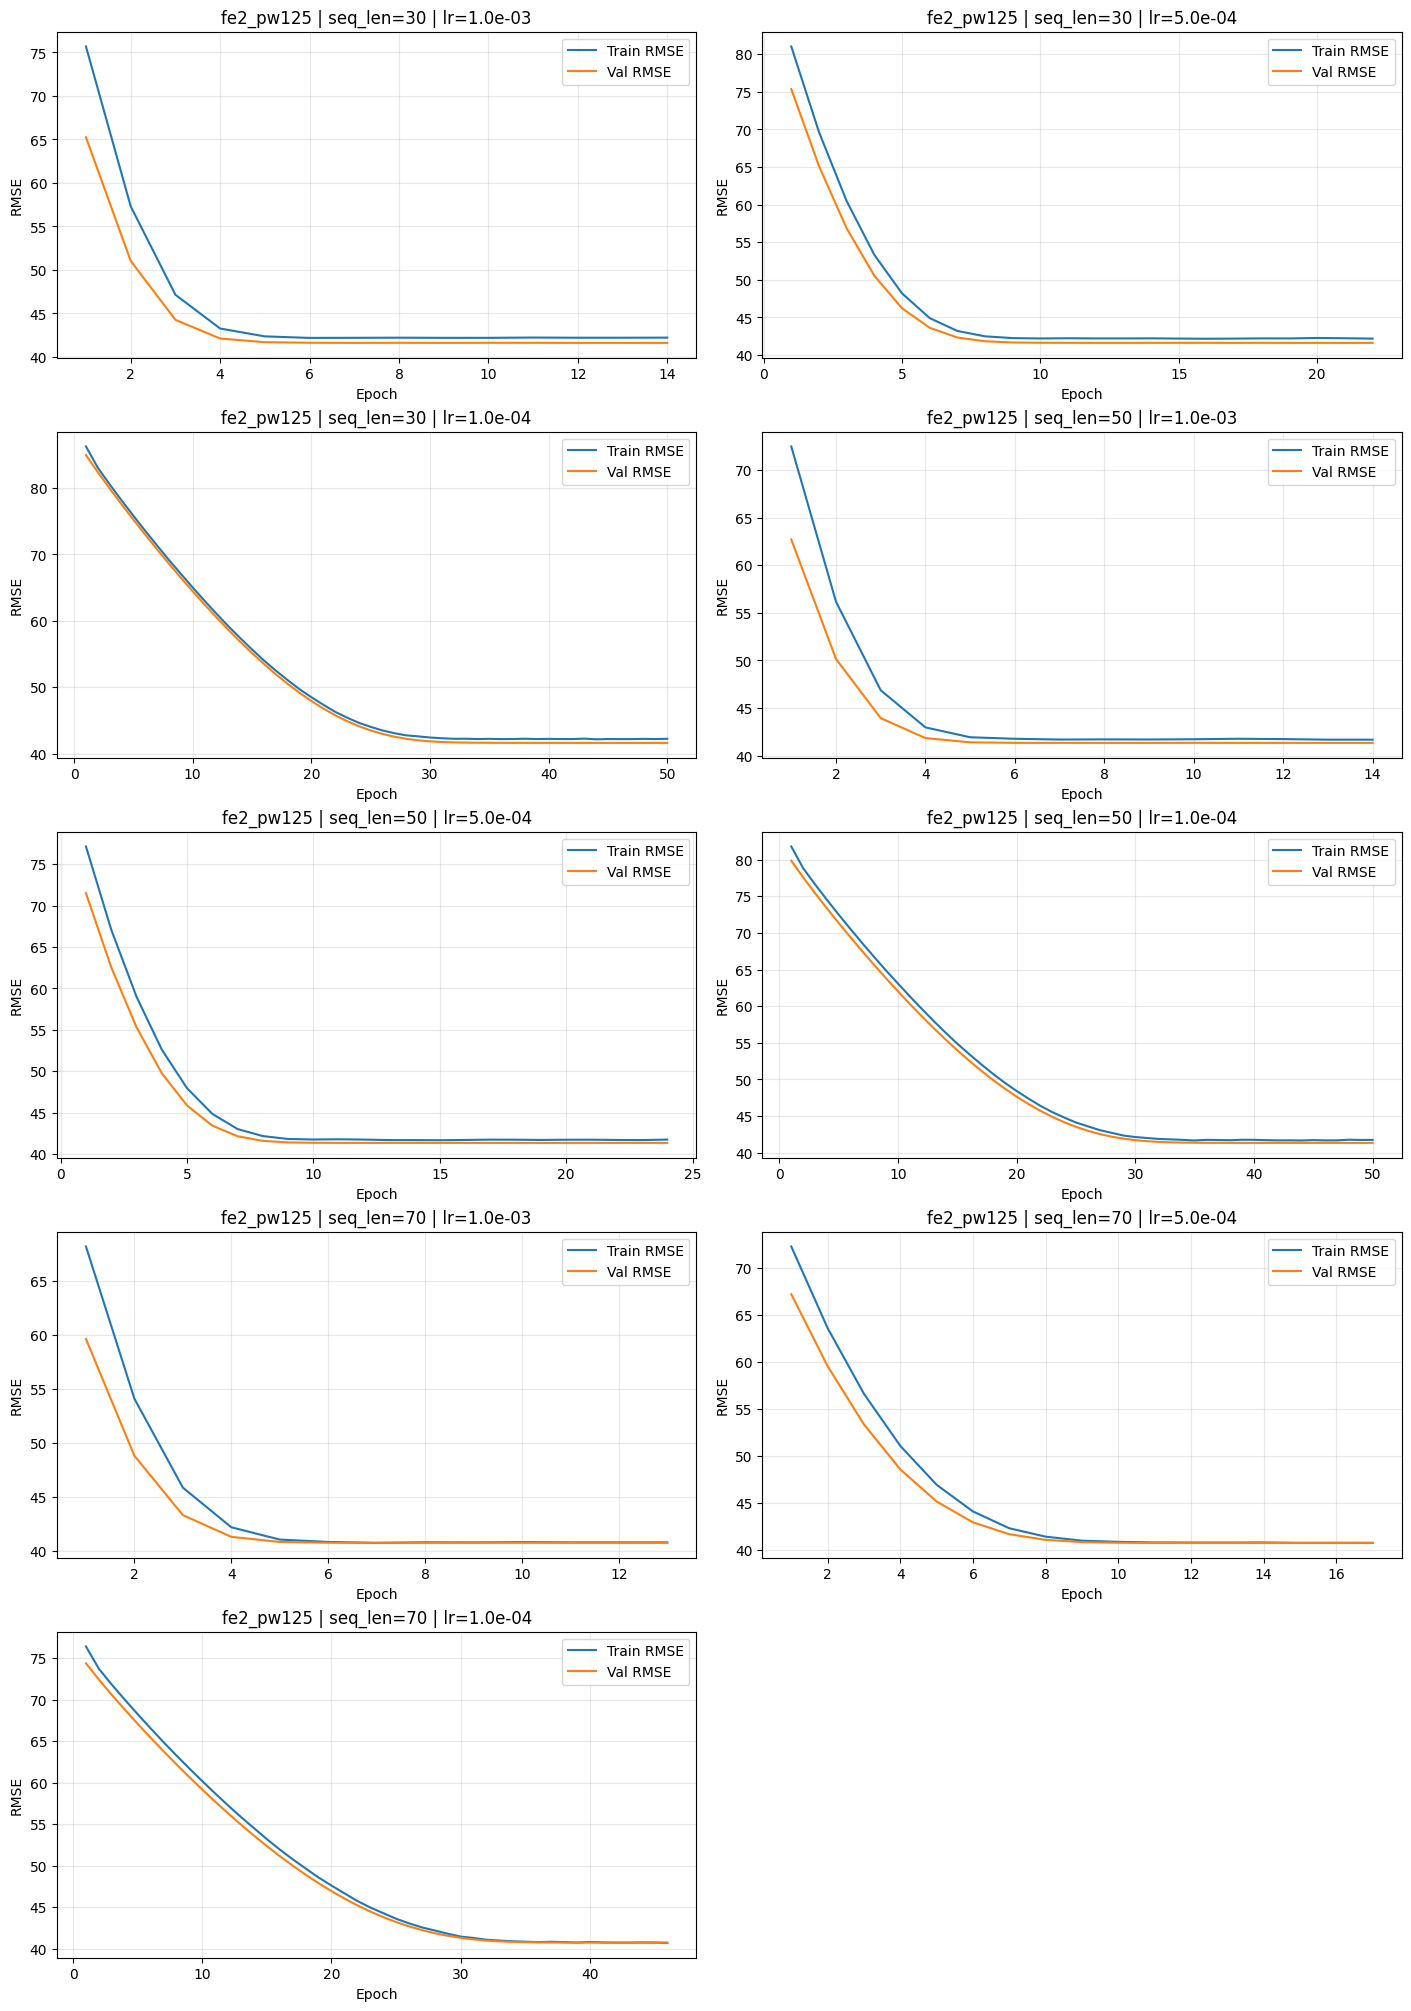

In [9]:
# Plot training curves (train/val RMSE) for each dataset + learning rate
n = len(histories)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, ((dataset_name, seq_len, lr), h) in enumerate(histories.items()):
    ax = axes[i]
    epochs_axis = np.arange(1, len(h["train_rmse"]) + 1)
    ax.plot(epochs_axis, h["train_rmse"], label="Train RMSE")
    ax.plot(epochs_axis, h["val_rmse"], label="Val RMSE")
    ax.set_title(f"{dataset_name} | seq_len={seq_len} | lr={lr:.1e}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.grid(alpha=0.3)
    ax.legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()